# Baco-Pangeome of Klebsiella 

In [12]:
# Imports
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import random

from pathlib import Path
from tqdm import tqdm

In [2]:
metadata_file = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/final/metadata_final_curated_slimmed.tsv"
metadata = pd.read_csv(metadata_file, sep="\t", low_memory=False)
print("Metadata shape before indexing:", metadata.shape)
print("Metadata columns:", metadata.columns.tolist())

Metadata shape before indexing: (88303, 157)
Metadata columns: ['Sample', 'is_kpsc', 'kpsc_final_list', 'is_refseq', 'is_nctc', 'species', 'species_match', 'Clonal group', 'LINcode', 'Phylogroup', 'Sublineage', 'scgST', 'contig_count', 'N50', 'largest_contig', 'total_size', 'ambiguous_bases', 'QC_warnings', 'ST', 'gapA', 'infB', 'mdh', 'pgi', 'phoE', 'rpoB', 'tonB', 'YbST', 'Yersiniabactin', 'ybtS', 'ybtX', 'ybtQ', 'ybtP', 'ybtA', 'irp2', 'irp1', 'ybtU', 'ybtT', 'ybtE', 'fyuA', 'spurious_ybt_hits', 'CbST', 'Colibactin', 'clbA', 'clbB', 'clbC', 'clbD', 'clbE', 'clbF', 'clbG', 'clbH', 'clbI', 'clbL', 'clbM', 'clbN', 'clbO', 'clbP', 'clbQ', 'spurious_clb_hits', 'AbST', 'Aerobactin', 'iucA', 'iucB', 'iucC', 'iucD', 'iutA', 'spurious_abst_hits', 'SmST', 'Salmochelin', 'iroB', 'iroC', 'iroD', 'iroN', 'spurious_smst_hits', 'RmST', 'RmpADC', 'rmpA', 'rmpD', 'rmpC', 'spurious_rmst_hits', 'virulence_score', 'spurious_virulence_hits', 'rmpA2', 'AGly_acquired', 'Col_acquired', 'Fcyn_acquired', 'Fl

In [3]:
# All metadata for SL258 (all columns)
sl258_metadata: pd.DataFrame = metadata.loc[metadata['Sublineage'] == 'SL258',:]

# How many samples are there
print(f"There are {len(sl258_metadata)} samples in SL258")
    #Print the number of samples in the sublineage (all rows)
cg_in_sublineage = sl258_metadata.loc[:, "Clonal group"].value_counts()
# Print the number of sublineages
print(f"Number of clonal groups: {len(cg_in_sublineage)}")
# Print sublineages with > 100 samples
print("Clonal groups with > 100 samples:")
print(cg_in_sublineage[cg_in_sublineage > 100])
cgs_of_interest = cg_in_sublineage[cg_in_sublineage > 100].index.tolist()

There are 16454 samples in SL258
Number of clonal groups: 25
Clonal groups with > 100 samples:
Clonal group
CG258      8847
CG340      3058
CG11       2981
CG3666      970
CG10268     445
Name: count, dtype: int64


In [4]:
# Take all samples from cgs of interest
sl258_samples = sl258_metadata[sl258_metadata["Clonal group"].isin(cgs_of_interest)]["Sample"].tolist()
# Randomly subsample to include 5% of each cg
sl258_samples = random.sample(sl258_samples, int(len(sl258_samples) * 0.01))
# Then collate all the bacfomer embeddings by opening all the bacformer embeddings file and appending them to a single pandas dataframe, indexed by sample
# Initialize an empty pandas dataframe to store embeddings
sl258_sample_embeddings = pd.DataFrame()

embeddings_dir = Path("/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/klebsiella_bacformer_embeddings")
# Loop through each sample in sl258_samples with a progress bar

count_existing_embeddings = 0
for sample in tqdm(sl258_samples, desc="Loading embeddings"):
      # Sample filename is sample_id_bacformer_embeddings.pt (a PyTorch file)
      sample_file = f"{sample}_bacformer_embeddings.pt"
      # Construct the path to the embeddings file
      sample_file_path = embeddings_dir / sample_file
      if sample_file_path.exists():
            # Read the embeddings file (PyTorch format)
            import torch
            sample_embeddings = torch.load(sample_file_path)
            # Pop the first dimension (samples)
            sample_embeddings = sample_embeddings.squeeze(0)
            # Convert to pandas dataframe
            sample_embeddings = pd.DataFrame({'embeddings': [sample_embeddings.numpy()]}, index=[sample])
            # Append the embeddings to the sl258_sample_embeddings dataframe
            sl258_sample_embeddings = pd.concat([sl258_sample_embeddings, sample_embeddings])
            count_existing_embeddings += 1
      else:
            print(f"Embeddings file for {sample} does not exist")

print("Embeddings shape:", sl258_sample_embeddings.shape)
print("Embeddings index (first 5):", sl258_sample_embeddings.index[:5])

Loading embeddings:   0%|          | 0/163 [00:00<?, ?it/s]

Loading embeddings:   1%|          | 1/163 [00:00<00:51,  3.12it/s]

Embeddings file for SAMN36585650 does not exist
Embeddings file for SAMN30333501 does not exist


Loading embeddings:   4%|▎         | 6/163 [00:02<01:03,  2.49it/s]

Embeddings file for SAMN37851065 does not exist


...

Embeddings file for SAMN36519382 does not exist
Embeddings file for SAMN40410178 does not exist
Embeddings file for SAMN41017077 does not exist
Embeddings file for SAMN37850701 does not exist


Loading embeddings:  98%|█████████▊| 160/163 [00:47<00:00,  4.08it/s]

Embeddings file for GCF_048754175.1_ASM4875417v1_genomic does not exist


Loading embeddings: 100%|██████████| 163/163 [00:48<00:00,  3.34it/s]

Embeddings shape: (91, 1)
Embeddings index (first 5): Index(['SAMN07525511', 'SAMN15868630', 'SAMN07525519', 'SAMN12343070',
       'SAMN14649885'],
      dtype='object')


In [13]:
# Explode embeddings: convert from 91 rows to ~455,000 rows
all_embeddings_list = []
sample_ids_list = []

for sample_id, row in sl258_sample_embeddings.iterrows():
    embedding_matrix = row['embeddings']  # Shape: (~5000, 960)
    all_embeddings_list.append(embedding_matrix)
    # Create sample_id array matching number of genes for this sample
    sample_ids_list.extend([sample_id] * len(embedding_matrix))

# Stack all embeddings into single array
embeddings_exploded = np.vstack(all_embeddings_list)  # Shape: (~455000, 960)

print(f"Exploded embeddings shape: {embeddings_exploded.shape}")
print(f"Sample IDs length: {len(sample_ids_list)}")

# Option 1: Keep as numpy array + separate sample ID list
# embeddings = embeddings_exploded
# sample_ids = sample_ids_list


Exploded embeddings shape: (484655, 960)
Sample IDs length: 484655


In [20]:
# Create obs DataFrame with sample_id and key metadata columns
obs_df = pd.DataFrame({'sample_id': sample_ids_list})

# Select key metadata columns to include in obs for easy plotting
metadata_cols_to_include = ['Clonal group', 'Sublineage', 'K_locus', 'K_type']

# Set Sample as index for merging
sample_metadata = sl258_metadata.set_index('Sample')

# Join the key metadata columns to obs_df
obs_with_metadata = obs_df.merge(
    sample_metadata[metadata_cols_to_include],
    left_on='sample_id',
    right_index=True,
    how='left'
)

print(f"obs_with_metadata shape: {obs_with_metadata.shape}")
print(f"obs_with_metadata columns: {obs_with_metadata.columns.tolist()}")
print(f"Embeddings shape: {embeddings_exploded.shape}")

# Create AnnData with gene-level embeddings and selected metadata
adata = ad.AnnData(X=embeddings_exploded, obs=obs_with_metadata)

# Store full sample-level metadata in adata.uns for reference if needed
adata.uns['sample_metadata'] = sample_metadata

print(f"\nAnnData X shape: {adata.X.shape}")
print(f"AnnData obs shape: {adata.obs.shape}")
print(f"AnnData obs columns: {adata.obs.columns.tolist()}")
print(f"Full sample metadata stored in adata.uns['sample_metadata']: {adata.uns['sample_metadata'].shape}")

# Check for any missing metadata
print(f"\nMissing metadata check:")
for col in metadata_cols_to_include:
    n_missing = adata.obs[col].isna().sum()
    print(f"  {col}: {n_missing} missing values")

obs_with_metadata shape: (484655, 5)
obs_with_metadata columns: ['sample_id', 'Clonal group', 'Sublineage', 'K_locus', 'K_type']
Embeddings shape: (484655, 960)

AnnData X shape: (484655, 960)
AnnData obs shape: (484655, 5)
AnnData obs columns: ['sample_id', 'Clonal group', 'Sublineage', 'K_locus', 'K_type']
Full sample metadata stored in adata.uns['sample_metadata']: (16454, 156)

Missing metadata check:
  Clonal group: 0 missing values
  Sublineage: 0 missing values
  K_locus: 0 missing values


/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


  K_type: 0 missing values


In [17]:
# Subsample 20 genomes - that is 20 * ~5000 = ~100,000 genes
# Get unique sample IDs and randomly sample 20
unique_sample_ids = adata.obs['sample_id'].unique().tolist()
sampled_genome_ids = random.sample(unique_sample_ids, 20)

print(f"Sampled {len(sampled_genome_ids)} genomes: {sampled_genome_ids[:5]}...")

# Subset the AnnData object to only genes from these 20 samples
adata_subset = adata[adata.obs['sample_id'].isin(sampled_genome_ids)].copy()

print(f"Subsetted AnnData shape: {adata_subset.shape}")
print(f"Number of unique samples in subset: {adata_subset.obs['sample_id'].nunique()}")

# Compute neighbors on the embedding space (X contains the 960-dim embeddings)
sc.pp.neighbors(adata_subset, n_neighbors=15, n_pcs=0)  # n_pcs=0 means use X directly

# Compute UMAP
sc.tl.umap(adata_subset)

print("UMAP computed successfully!")
print(f"UMAP coordinates shape: {adata_subset.obsm['X_umap'].shape}")

Sampled 20 genomes: ['SAMEA113935188', 'SAMN10986372', 'SAMEA7564646', 'SAMEA4916074', 'SAMN12343070']...
Subsetted AnnData shape: (106774, 960)
Number of unique samples in subset: 20
UMAP computed successfully!
UMAP coordinates shape: (106774, 2)


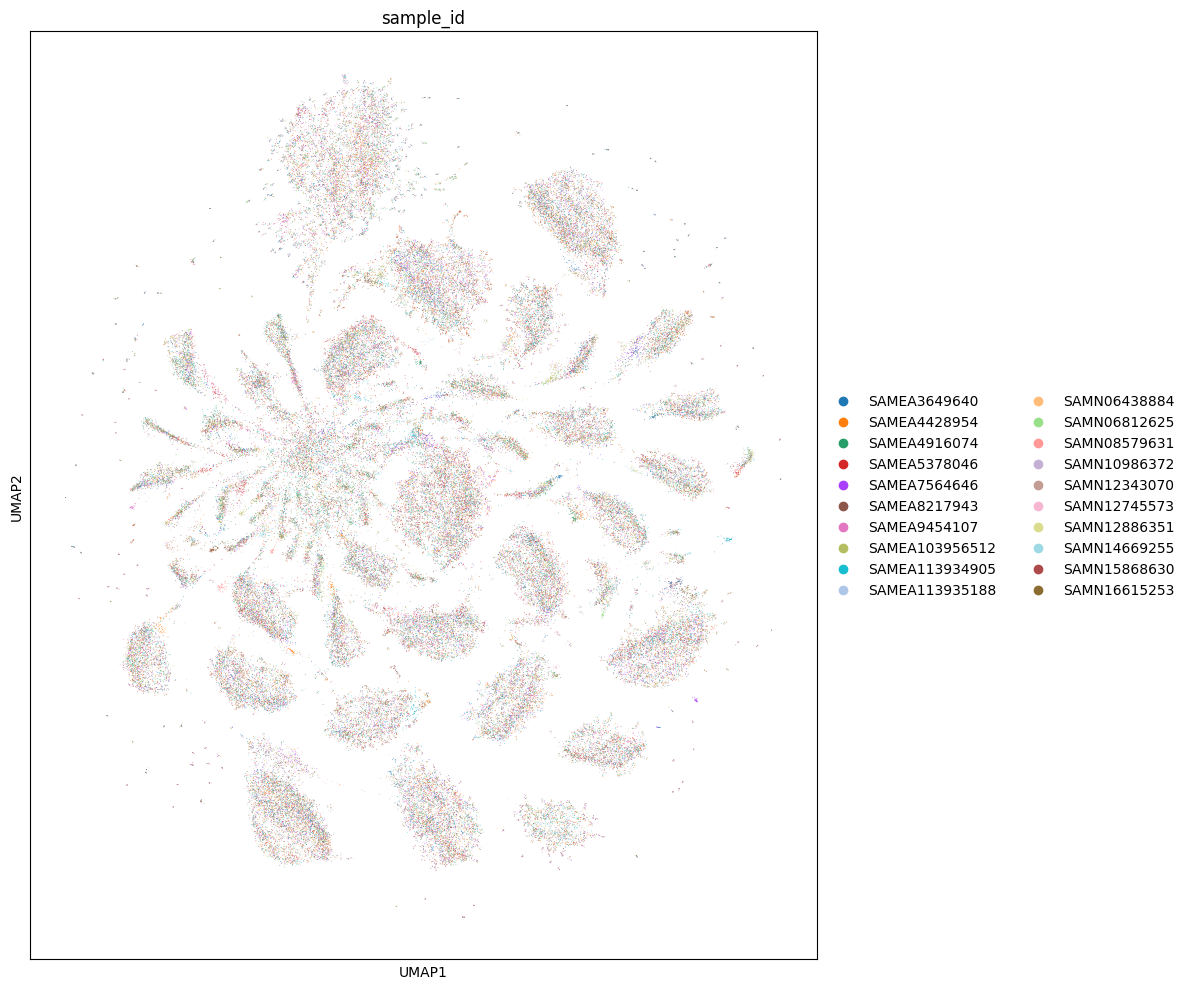


Total points plotted: 106774
Number of samples (colors): 20


In [18]:
# Plot UMAP colored by Sample ID
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP colored by sample_id
sc.pl.umap(adata_subset, color='sample_id', ax=ax, show=False, legend_loc='right margin')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal points plotted: {adata_subset.shape[0]}")
print(f"Number of samples (colors): {adata_subset.obs['sample_id'].nunique()}")

In [22]:
# Subsample 20 genomes - that is 20 * ~5000 = ~100,000 genes
# Get unique sample IDs and randomly sample 20
unique_sample_ids = adata.obs['sample_id'].unique().tolist()
# Subsample 20 that are all part of Clonal group CG258
cg258_samples = adata.obs[adata.obs['Clonal group'] == 'CG258']['sample_id'].unique().tolist()
cg258_genome_ids = random.sample(cg258_samples, 20)

print(f"Sampled {len(cg258_genome_ids)} genomes: {cg258_genome_ids[:5]}...")

# Subset the AnnData object to only genes from these 20 samples
adata_cg258_sampled_subset = adata[adata.obs['sample_id'].isin(cg258_genome_ids)].copy()

print(f"Subsetted AnnData shape: {adata_cg258_sampled_subset.shape}")
print(f"Number of unique samples in subset: {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")

# Compute neighbors on the embedding space (X contains the 960-dim embeddings)
sc.pp.neighbors(adata_cg258_sampled_subset, n_neighbors=15, n_pcs=0)  # n_pcs=0 means use X directly

# Compute UMAP
sc.tl.umap(adata_cg258_sampled_subset)

print("UMAP computed successfully!")
print(f"UMAP coordinates shape: {adata_cg258_sampled_subset.obsm['X_umap'].shape}")

Sampled 20 genomes: ['SAMEA1920840', 'SAMEA49376668', 'SAMN17600186', 'SAMN15868605', 'SAMN17600120']...
Subsetted AnnData shape: (108494, 960)
Number of unique samples in subset: 20


/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited at iteration 2000 with accuracies 
[1.78102863e-13 3.35858280e-07 6.85280208e-07 1.08079578e-05]
not reaching the requested tolerance 1.0132789611816406e-06.
Use iteration 1928 instead with accuracy 
1.3096553388990004e-06.

  _, diffusion_map = lobpcg(
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[4.60771088e-15 3.36743721e-07 4.30015479e-07 4.47185705e-06]
not reaching the requested tolerance 1.0132789611816406e-06.
  _, diffusion_map = lobpcg(


UMAP computed successfully!
UMAP coordinates shape: (108494, 2)


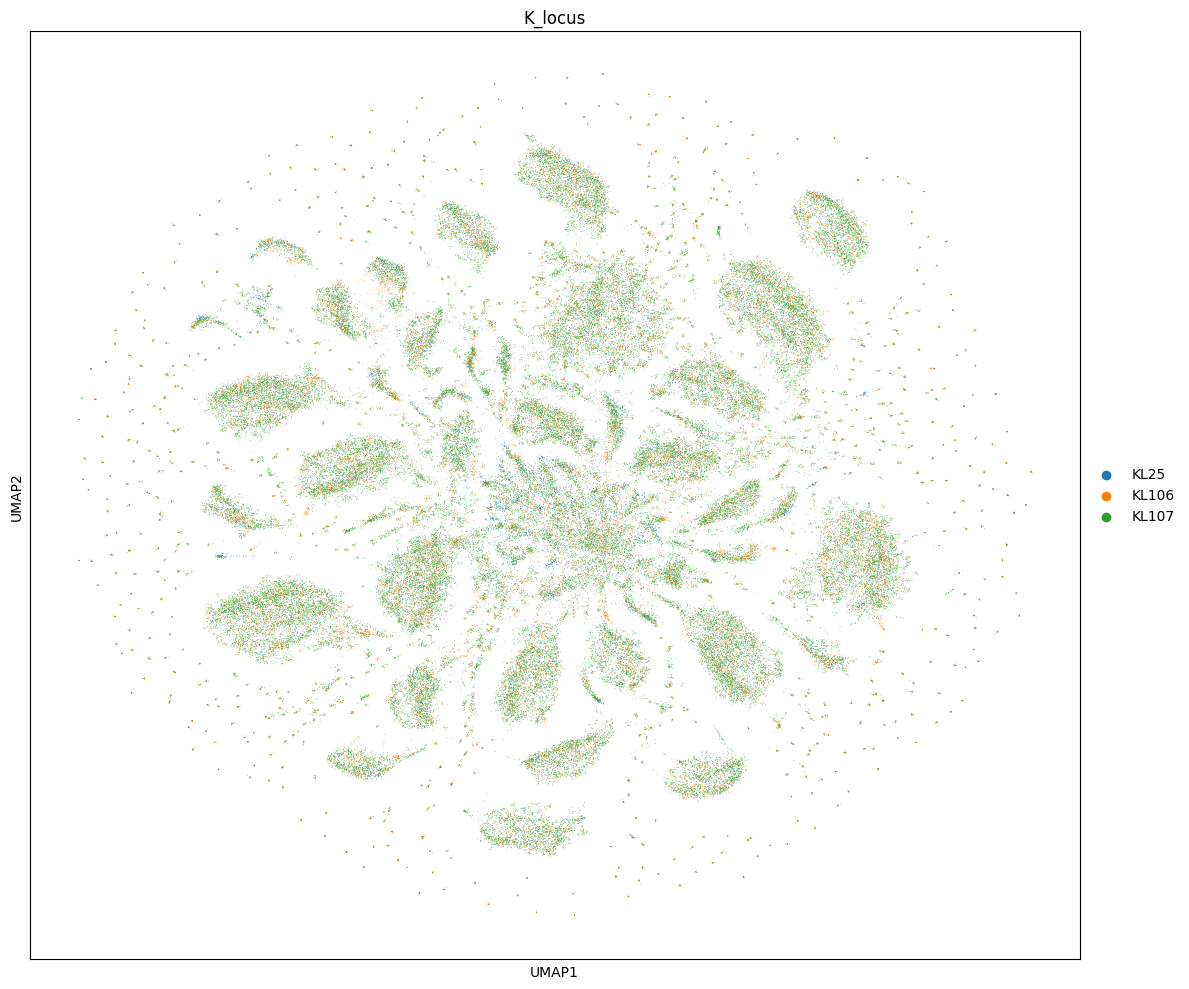


Total points plotted: 108494
Number of samples (colors): 20


In [24]:
# Plot UMAP colored by Sample ID
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP colored by sample_id
sc.pl.umap(adata_subset, color='K_locus', ax=ax, show=False, legend_loc='right margin')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal points plotted: {adata_subset.shape[0]}")
print(f"Number of samples (colors): {adata_subset.obs['sample_id'].nunique()}")